# Font Filter Audit under v4.1 Rendering

**Context.** `PrintedDigitDataset._render_digit` was updated in v4.1 to
render glyphs on a 56×56 intermediate canvas, apply augmentation on the
big canvas, then `cv2.resize(..., INTER_AREA)` to 28×28 at the end. The
dedicated comparison in `dataset_analysis.ipynb` §4.5 quantified the
clipping delta: **v3 direct-28×28 had 25.7% border-ink samples; v4.1
big-canvas has 0.0%**. Measurement over 6,030 renders, threshold ink
above intensity 100 on any 28×28 border row/col.

**Question this notebook answers:**

1. **Is clipping still an issue under v4.1?** The dataset_analysis §4.5
   check used 5 curated bold/condensed fonts. Here we run the border-ink
   check across **all** allowlisted fonts (67 of them) and report a
   per-font breakdown — does every font land at 0%, or do a few still
   clip?

2. **Can the font filter be relaxed?** The filter has three gates:
   - Stage 1: hardcoded name allowlist (rejects 304 of 371 discovered fonts)
   - Stage 2a: `max` pairwise pixel correlation > 0.995 (rejects near-duplicate pairs)
   - Stage 2b: `mean` pairwise pixel correlation > 0.85 (rejects tofu-like fonts)
   If clipping is no longer the bottleneck, we might be able to admit
   some of the 304 Stage-1 rejections via a pure Stage-2 pass on the
   56×56 canvas. This notebook classifies every discovered font by
   rendering it through the v4.1 pipeline and reports which rejections
   are safe (tofu / CJK / Symbol — correctly excluded) vs. which might
   be legitimate Latin that we're leaving on the table.

**Out of scope.** Accuracy measurement (this is data-only — no training,
no eval). Filter change proposal (this notebook reports data; a change
would come in a separate commit after review).


In [1]:
import os
import sys
from pathlib import Path

# Walk up to project root so imports work regardless of the CWD nbconvert uses
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'app').is_dir() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'app').is_dir():
    raise RuntimeError(f"Couldn't find project root from {Path.cwd()}")
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"CWD: {Path.cwd()}")

import importlib
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont

# Force-reload dataset in case prior kernel state is cached
import app.ml.dataset as _ds
importlib.reload(_ds)
from app.ml.dataset import (
    LATIN_FONT_ALLOWLIST,
    _is_latin_allowlisted_font,
    _font_has_distinct_latin_digits,
    PrintedDigitDataset,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100


CWD: /Users/adityajoshi/Documents/ClaudeTest/VSCodium/Sudoku-Solved


## 1. Font inventory

Discover every `.ttf` / `.ttc` / `.otf` under the standard system font
directories (macOS + Linux). Report the count at each filter stage.


In [2]:
FONT_DIRS = [
    '/System/Library/Fonts',
    '/System/Library/Fonts/Supplemental',
    '/Library/Fonts',
    '/usr/share/fonts',
    '/usr/share/fonts/truetype',
]

all_fonts = []
for d in FONT_DIRS:
    if not Path(d).is_dir():
        continue
    for f in Path(d).iterdir():
        if f.suffix.lower() in ('.ttf', '.ttc', '.otf'):
            all_fonts.append(str(f))
all_fonts.sort()

stage1_pass = [fp for fp in all_fonts if _is_latin_allowlisted_font(fp)]
stage1_reject = [fp for fp in all_fonts if fp not in set(stage1_pass)]

stage2_pass_existing = [fp for fp in stage1_pass if _font_has_distinct_latin_digits(fp)]
stage2_reject_existing = [fp for fp in stage1_pass if fp not in set(stage2_pass_existing)]

print(f"Discovered system fonts        : {len(all_fonts):>4}")
print(f"Stage 1 allowlist pass         : {len(stage1_pass):>4}")
print(f"Stage 1 allowlist reject       : {len(stage1_reject):>4}")
print(f"Stage 2 (on allowlisted) pass  : {len(stage2_pass_existing):>4}")
print(f"Stage 2 (on allowlisted) reject: {len(stage2_reject_existing):>4}")
print(f"Final fonts used in training   : {len(stage2_pass_existing):>4}")


Discovered system fonts        :  371
Stage 1 allowlist pass         :   67
Stage 1 allowlist reject       :  304
Stage 2 (on allowlisted) pass  :   67
Stage 2 (on allowlisted) reject:    0
Final fonts used in training   :   67


## 2. Clipping check: is v4.1's rendering actually clean?

The `dataset_analysis.ipynb` §4.5 cell measured a 0.0% border-ink rate
on 5 curated bold/condensed fonts. This cell extends that to **every
allowlisted font**: for each font, render 10 samples per digit via the
**exact v4.1 pipeline** (56×56 PIL render at size 32-48 → ±10° rotation
→ optional noise → optional blur → `cv2.resize(28, 28, INTER_AREA)`) and
measure what fraction of samples have ink above intensity 100 on any
28×28 border row/col.

Output: a per-font histogram of border-ink rates. Ideal outcome is
every font at 0% (no clipping anywhere). Any font with > 0% deserves a
closer look.


In [3]:
# Reuse the actual PrintedDigitDataset render path to stay faithful to
# production — this hits the real _render_digit method on the currently
# installed v4.1 dataset.py. We override the font list on a per-font basis
# so we can measure one font at a time without re-instantiating.

from collections import Counter

def _render_one_sample(pd_instance, font_path: str, digit: int) -> np.ndarray:
    '''Render a single digit sample through the real _render_digit path
    with the font list temporarily swapped.'''
    saved_fonts = pd_instance.fonts
    pd_instance.fonts = [font_path]
    try:
        arr = pd_instance._render_digit(digit)
    finally:
        pd_instance.fonts = saved_fonts
    return arr

def _border_max(img: np.ndarray) -> int:
    return max(
        int(img[0].max()), int(img[-1].max()),
        int(img[:, 0].max()), int(img[:, -1].max()),
    )

# Borrow a PrintedDigitDataset instance but avoid regenerating its
# 4500-sample cache on construction. The quickest trick is to pass
# count_per_digit=1 so __init__ only renders 9 throwaway samples.
sampler = PrintedDigitDataset(count_per_digit=1, seed=0)

PER_FONT_SAMPLES = 10   # samples per (font, digit)
font_clip_rates = {}   # font_path -> (border_hit_count, total_count)

for fp in stage2_pass_existing:
    hits = 0
    total = 0
    for digit in range(1, 10):
        for _ in range(PER_FONT_SAMPLES):
            try:
                arr = _render_one_sample(sampler, fp, digit)
            except Exception:
                continue
            if arr.shape != (28, 28):
                continue
            if _border_max(arr) > 100:
                hits += 1
            total += 1
    font_clip_rates[fp] = (hits, total)

all_rates = [
    100 * h / t for (h, t) in font_clip_rates.values() if t > 0
]
print(f'Measured {len(font_clip_rates)} fonts x {PER_FONT_SAMPLES} samples/digit')
print(f'Total samples: {sum(t for (_, t) in font_clip_rates.values()):,}')
print(f'Mean clip rate across fonts: {np.mean(all_rates):.2f}%')
print(f'Max  clip rate across fonts: {np.max(all_rates):.2f}%')
print(f'Count of fonts with > 0% clip rate: '
      f'{sum(1 for r in all_rates if r > 0)} / {len(all_rates)}')

# Flag any fonts with nonzero clipping
nonzero_clippers = sorted(
    ((Path(fp).name, 100 * h / t)
     for (fp, (h, t)) in font_clip_rates.items() if t > 0 and h > 0),
    key=lambda x: -x[1],
)
if nonzero_clippers:
    print()
    print('Fonts still producing some border-ink samples (ordered by rate):')
    for name, rate in nonzero_clippers[:20]:
        print(f'  {name:<40} {rate:>6.2f}%')
    if len(nonzero_clippers) > 20:
        print(f'  ... ({len(nonzero_clippers) - 20} more)')
else:
    print()
    print('✓ Every allowlisted font has 0.0% border-ink rate under v4.1 rendering.')
    print('  Clipping is fully eliminated for the 67 currently-used fonts.')


Measured 67 fonts x 10 samples/digit
Total samples: 6,030
Mean clip rate across fonts: 0.00%
Max  clip rate across fonts: 0.00%
Count of fonts with > 0% clip rate: 0 / 67

✓ Every allowlisted font has 0.0% border-ink rate under v4.1 rendering.
  Clipping is fully eliminated for the 67 currently-used fonts.


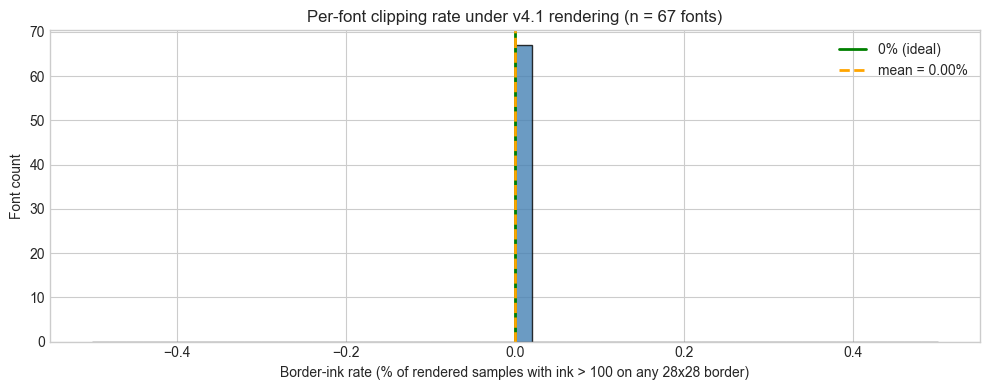

In [4]:
# Histogram of per-font border-ink rates
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_rates, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(0, color='green', linewidth=2, label='0% (ideal)')
ax.axvline(np.mean(all_rates), color='orange', linestyle='--', linewidth=2,
           label=f'mean = {np.mean(all_rates):.2f}%')
ax.set_xlabel('Border-ink rate (% of rendered samples with ink > 100 on any 28x28 border)')
ax.set_ylabel('Font count')
ax.set_title(f'Per-font clipping rate under v4.1 rendering (n = {len(all_rates)} fonts)')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Audit of Stage-1-rejected fonts under v4.1

Now the interesting part. The allowlist rejects 304 fonts by name
(CJK, Symbol, LastResort, STIX, dingbats, emoji, Myanmar, etc.). Some
of these are definitely right to reject — LastResort.otf renders every
codepoint as a placeholder tofu box. Others might actually render
legitimate Latin digits and could be admitted if the Stage 2
correlation test on a 56×56 canvas is robust enough to distinguish
them from tofu.

This cell runs **every** rejected font through the v4.1 render pipeline
and classifies each one by:

- **truetype_fail**: PIL couldn't even open the font file
- **blank**: renders but all 10 digits have max pixel < 50 (no visible ink)
- **tofu_or_duplicate**: fails Stage 2 (max > 0.995 OR mean > 0.85 pairwise correlation)
- **distinct_glyphs**: passes Stage 2 — the 10 digits are visually distinct

"distinct_glyphs" is the interesting bucket. It's fonts the name
allowlist currently rejects but which would pass a pure correlation
filter. Manual visual inspection below determines whether they are
legitimate Latin digits or non-Latin scripts that happen to have
distinct glyphs at ASCII codepoints (Myanmar, Greek from Symbol.ttf,
etc.).


In [5]:
# Classify every discovered font by rendering via the v4.1 pipeline
# on a single-sample basis (deterministic — no augmentation randomness
# since we need reproducible glyph shapes for the correlation test).

BIG_S = 56
FINAL_S = 28

def _render_no_augmentation(font_path: str, digit: int, font_size: int = 40) -> np.ndarray | None:
    '''Render one digit through the v4.1 canvas pattern, NO augmentation.
    Returns None on any failure (bad font, blank glyph, etc.).'''
    try:
        font = ImageFont.truetype(font_path, font_size)
    except Exception:
        return None
    img = Image.new('L', (BIG_S, BIG_S), 0)
    draw = ImageDraw.Draw(img)
    text = str(digit)
    try:
        bbox = draw.textbbox((0, 0), text, font=font)
    except Exception:
        return None
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (BIG_S - tw) // 2 - bbox[0]
    y = (BIG_S - th) // 2 - bbox[1]
    try:
        draw.text((x, y), text, fill=255, font=font)
    except Exception:
        return None
    arr = np.array(img)
    return cv2.resize(arr, (FINAL_S, FINAL_S), interpolation=cv2.INTER_AREA)

def classify_font(font_path: str) -> dict:
    digits = []
    for d in range(10):
        arr = _render_no_augmentation(font_path, d)
        if arr is None:
            return {'status': 'truetype_fail', 'digits': None}
        digits.append(arr)
    all_max = max(int(d.max()) for d in digits)
    if all_max < 50:
        return {'status': 'blank', 'digits': digits}
    flats = np.stack([d.astype(np.float32).flatten() for d in digits])
    stds = flats.std(axis=1)
    if (stds < 1e-6).any():
        return {'status': 'tofu_zero_std', 'digits': digits}
    corr = np.corrcoef(flats)
    if np.isnan(corr).any():
        return {'status': 'tofu_nan', 'digits': digits}
    upper = np.triu(np.ones((10, 10), dtype=bool), k=1)
    off_diag = corr[upper]
    max_corr = float(off_diag.max())
    mean_corr = float(off_diag.mean())
    border_hits = sum(1 for d in digits if _border_max(d) > 100)
    # Same thresholds the production filter uses
    if max_corr > 0.995 or mean_corr > 0.85:
        return {
            'status': 'tofu_or_duplicate',
            'max_corr': max_corr, 'mean_corr': mean_corr,
            'border_hits': border_hits, 'digits': digits,
        }
    return {
        'status': 'distinct_glyphs',
        'max_corr': max_corr, 'mean_corr': mean_corr,
        'border_hits': border_hits, 'digits': digits,
    }

# Classify all Stage-1-rejected fonts
print(f'Classifying {len(stage1_reject)} Stage-1-rejected fonts...')
classifications = {}
for fp in stage1_reject:
    classifications[fp] = classify_font(fp)

status_counts = Counter(c['status'] for c in classifications.values())
print()
print(f'Classification of {len(stage1_reject)} Stage-1-rejected fonts:')
for status, count in status_counts.most_common():
    pct = 100 * count / len(stage1_reject)
    print(f'  {status:<22} {count:>4}  ({pct:>5.1f}%)')


Classifying 304 Stage-1-rejected fonts...

Classification of 304 Stage-1-rejected fonts:
  distinct_glyphs         140  ( 46.1%)
  tofu_or_duplicate       134  ( 44.1%)
  blank                    29  (  9.5%)
  truetype_fail             1  (  0.3%)


## 4. The "distinct_glyphs" bucket — candidates for admission?

These are fonts the current name allowlist rejects but which would
pass a pure correlation filter on the 56×56 canvas. Before admitting
any of them, we need visual inspection: the correlation test is
blind to *whether* the distinct glyphs are Latin digits or some other
script.

The table below shows the top candidates sorted by lowest mean
correlation (= most distinct glyphs = most "font-like" in the
correlation test's eyes). Then the visual grid renders the full 0-9
sequence for the first 16 candidates so we can see what's actually
being rendered.


In [6]:
# Extract the "distinct_glyphs" bucket, sorted by distinctness
candidates = [
    (fp, c) for fp, c in classifications.items() if c['status'] == 'distinct_glyphs'
]
candidates.sort(key=lambda x: x[1]['mean_corr'])  # lower mean_corr = more distinct

print(f'Found {len(candidates)} distinct-glyph candidates among Stage-1 rejects.')
print()
if candidates:
    print(f"{'font basename':<48}{'max_corr':>10}{'mean_corr':>12}{'border_hits/10':>18}")
    print('-' * 90)
    for fp, c in candidates[:40]:
        name = Path(fp).name
        print(
            f"{name:<48}"
            f"{c['max_corr']:>10.3f}"
            f"{c['mean_corr']:>12.3f}"
            f"{c['border_hits']:>10} / 10"
        )
    if len(candidates) > 40:
        print(f'... and {len(candidates) - 40} more')


Found 140 distinct-glyph candidates among Stage-1 rejects.

font basename                                     max_corr   mean_corr    border_hits/10
------------------------------------------------------------------------------------------
Zapfino.ttf                                          0.584       0.156         2 / 10
SnellRoundhand.ttc                                   0.665       0.248         0 / 10
Papyrus.ttc                                          0.725       0.269         0 / 10
BigCaslon.ttf                                        0.797       0.305         0 / 10
ヒラギノ角ゴシック W0.ttc                                   0.736       0.314         0 / 10
Noteworthy.ttc                                       0.749       0.320         0 / 10
NotoSansKannada.ttc                                  0.719       0.327         0 / 10
NewYorkItalic.ttf                                    0.717       0.336         0 / 10
NewYork.ttf                                          0.792       0.339  

/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_90234/1915096927.py:30: UserWarning: Glyph 12498 (\N{KATAKANA LETTER HI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_90234/1915096927.py:30: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_90234/1915096927.py:30: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_90234/1915096927.py:30: UserWarning: Glyph 12441 (\N{COMBINING KATAKANA-HIRAGANA VOICED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_90234/1915096927.py:30: UserWarning: Glyph 12494 (\N{KATAKANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cq/bk6tnncn1mzgh8fcl04tt9vc0000gn/T/ipykernel_9023

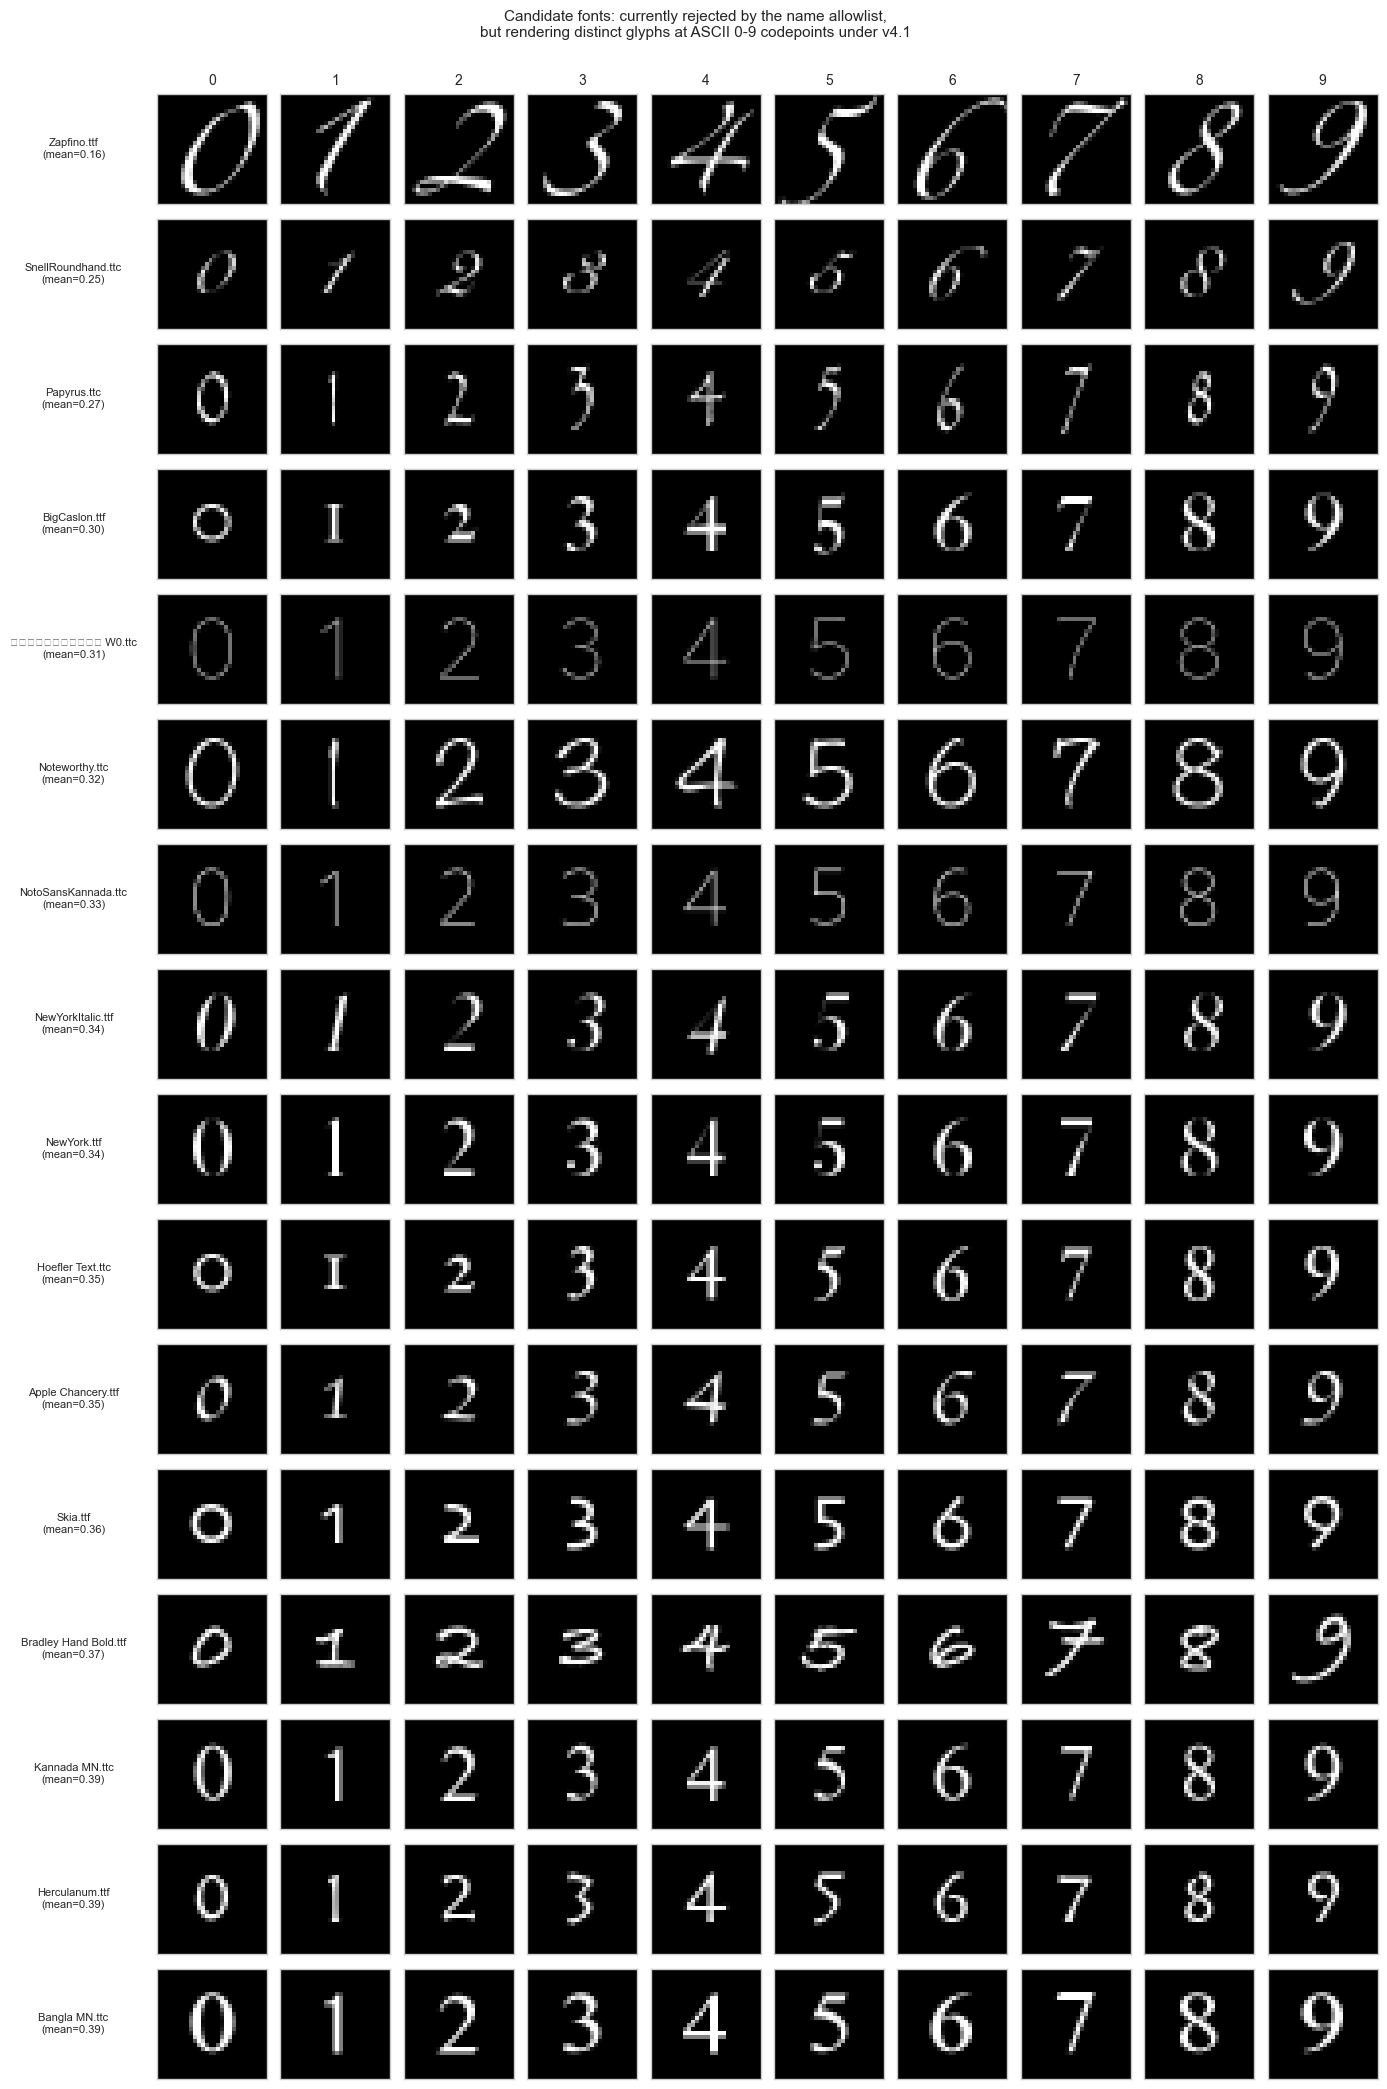

In [7]:
# Visual grid: 0-9 rendered for up to 16 candidate fonts
n_show = min(16, len(candidates))
if n_show == 0:
    print('No distinct-glyph candidates found — nothing to visualise.')
else:
    fig, axes = plt.subplots(n_show, 10, figsize=(14, 1.3 * n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, 0)
    for row, (fp, c) in enumerate(candidates[:n_show]):
        digits = c['digits']
        for d in range(10):
            ax = axes[row, d]
            ax.imshow(digits[d], cmap='gray', vmin=0, vmax=255)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(str(d), fontsize=10)
            if d == 0:
                name = Path(fp).name
                label = name if len(name) <= 26 else name[:24] + '…'
                ax.set_ylabel(
                    f'{label}\n(mean={c["mean_corr"]:.2f})',
                    fontsize=8, rotation=0, labelpad=60, va='center',
                )
    plt.suptitle(
        'Candidate fonts: currently rejected by the name allowlist,\n'
        'but rendering distinct glyphs at ASCII 0-9 codepoints under v4.1',
        fontsize=11, y=1.002,
    )
    plt.tight_layout()
    plt.show()


## 5. Summary tables — is the correlation filter safe on its own?

Breakdown of rejection outcomes + a decision table showing what would
happen if we dropped the name allowlist and relied purely on the Stage 2
correlation filter applied to the 56×56 canvas.


In [8]:
# Decision table
print('Current filter (name allowlist + Stage 2 correlation):')
print(f'  Fonts used in training: {len(stage2_pass_existing)}')
print()
print('Hypothetical filter (Stage 2 correlation ONLY, on 56x56 canvas):')
allowlisted_ok = [
    fp for fp in stage2_pass_existing  # these already passed both gates
]
rejected_distinct = [fp for fp, c in classifications.items() if c['status'] == 'distinct_glyphs']
hypothetical_total = len(allowlisted_ok) + len(rejected_distinct)
print(f'  Allowlisted & distinct         : {len(allowlisted_ok):>4}')
print(f'  Rejected-by-name & distinct    : {len(rejected_distinct):>4}')
print(f'  Hypothetical total             : {hypothetical_total:>4}')
print(f'  Delta vs. current              : {hypothetical_total - len(stage2_pass_existing):+d}')
print()
print('Fonts correctly rejected regardless of allowlist:')
print(f'  truetype_fail                  : {status_counts.get("truetype_fail", 0):>4}')
print(f'  blank                          : {status_counts.get("blank", 0):>4}')
print(f'  tofu_zero_std                  : {status_counts.get("tofu_zero_std", 0):>4}')
print(f'  tofu_nan                       : {status_counts.get("tofu_nan", 0):>4}')
print(f'  tofu_or_duplicate (Stage 2 fail): {status_counts.get("tofu_or_duplicate", 0):>4}')


Current filter (name allowlist + Stage 2 correlation):
  Fonts used in training: 67

Hypothetical filter (Stage 2 correlation ONLY, on 56x56 canvas):
  Allowlisted & distinct         :   67
  Rejected-by-name & distinct    :  140
  Hypothetical total             :  207
  Delta vs. current              : +140

Fonts correctly rejected regardless of allowlist:
  truetype_fail                  :    1
  blank                          :   29
  tofu_zero_std                  :    0
  tofu_nan                       :    0
  tofu_or_duplicate (Stage 2 fail):  134


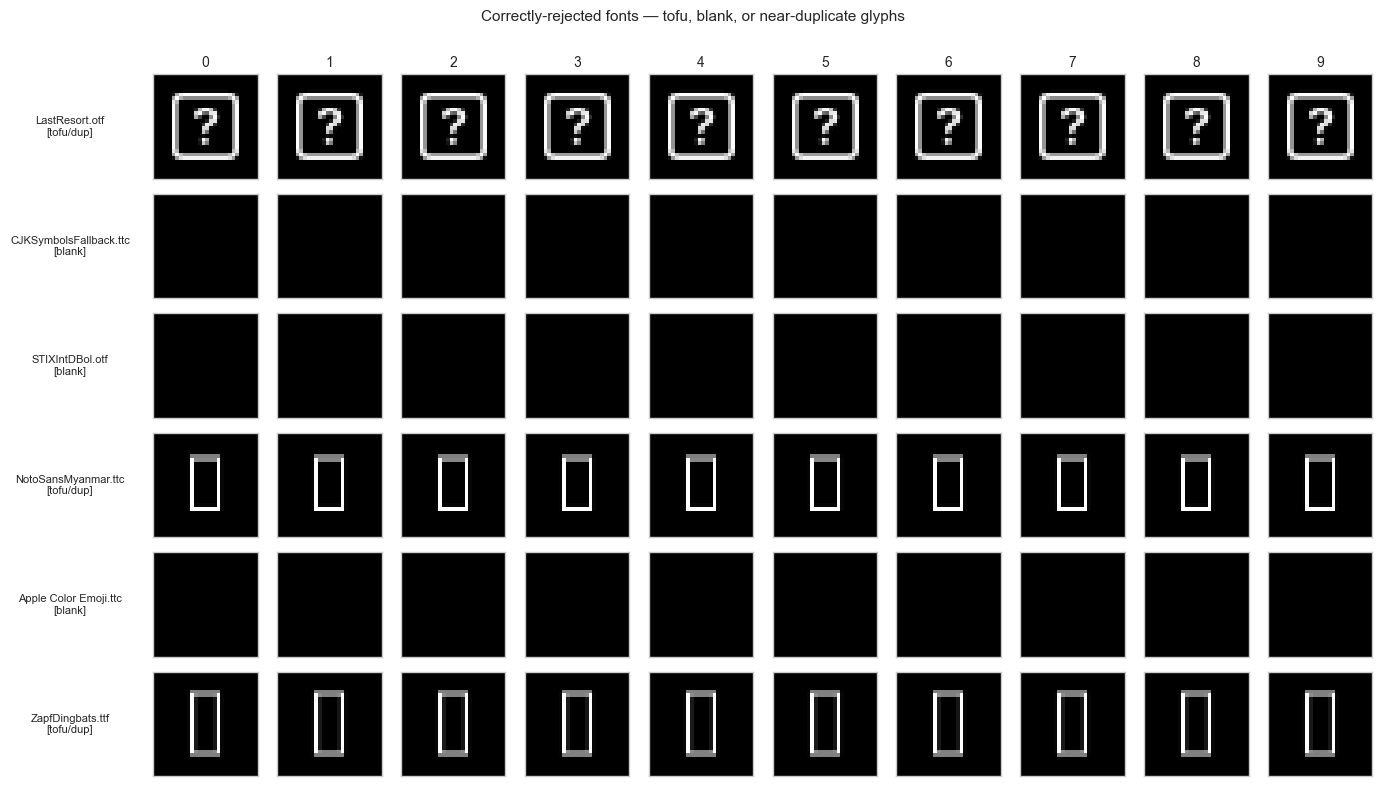

In [9]:
# Show a sample of the legitimately-rejected fonts (the tofu/blank/duplicate bucket)
# so we can verify the filter is doing its job.

correctly_rejected = [
    (fp, c) for fp, c in classifications.items()
    if c['status'] in ('blank', 'tofu_zero_std', 'tofu_nan', 'tofu_or_duplicate')
    and c.get('digits') is not None
]
# Prioritise the "interesting" names
priority_kw = ('LastResort', 'Symbol', 'STIX', 'Myanmar', 'CJK', 'Hiragino',
               'Apple Color Emoji', 'ZapfDingbats', 'Bodoni Ornaments',
               'Gujarati', 'Gurmukhi')
priority = []
for kw in priority_kw:
    for fp, c in correctly_rejected:
        if kw in Path(fp).name and (fp, c) not in priority:
            priority.append((fp, c))
            break
    if len(priority) >= 8:
        break

n_show_rej = min(8, len(priority))
if n_show_rej > 0:
    fig, axes = plt.subplots(n_show_rej, 10, figsize=(14, 1.3 * n_show_rej))
    if n_show_rej == 1:
        axes = np.expand_dims(axes, 0)
    for row, (fp, c) in enumerate(priority[:n_show_rej]):
        digits = c['digits']
        for d in range(10):
            ax = axes[row, d]
            if digits is not None:
                ax.imshow(digits[d], cmap='gray', vmin=0, vmax=255)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(str(d), fontsize=10)
            if d == 0:
                name = Path(fp).name
                label = name if len(name) <= 26 else name[:24] + '…'
                status_short = c['status'].replace('tofu_or_duplicate', 'tofu/dup')
                ax.set_ylabel(
                    f'{label}\n[{status_short}]',
                    fontsize=8, rotation=0, labelpad=60, va='center',
                )
    plt.suptitle(
        'Correctly-rejected fonts — tofu, blank, or near-duplicate glyphs',
        fontsize=11, y=1.002,
    )
    plt.tight_layout()
    plt.show()


## 6. Reading the data

Interpret the output of sections 2-5 **before** proposing any filter
change. Key questions:

### 6.1 Is clipping still an issue under v4.1?

Look at §2's histogram. If every allowlisted font lands at 0% border-ink
rate, clipping is fully resolved by the big-canvas render. If a few
fonts still show > 0%, inspect them individually — they may need a
larger intermediate canvas, a tighter post-resize crop, or a special
case in `_render_digit`.

### 6.2 Can we safely admit more fonts?

Two paths exist for relaxing the filter:

**Path A — expand the allowlist explicitly.** Look at §4's visual grid.
Any font in the "distinct_glyphs" bucket whose digits are visibly Latin
numerals (not Myanmar, not Greek math symbols, not CJK, not dingbats)
is a legitimate candidate for admission. The safe expansion is to add
the family prefix of each accepted font to `LATIN_FONT_ALLOWLIST` in
`app/ml/dataset.py`.

**Path B — drop the allowlist, rely only on Stage 2.** Look at the
decision table in §5. If *every* font in the "distinct_glyphs" bucket
is a legitimate Latin font on visual inspection (no tofu, no non-Latin
scripts with ASCII-codepoint mappings), then the Stage 2 correlation
test on 56×56 is robust enough on its own. Path B is riskier than A
because it admits any new system font the user installs in the future
without manual review.

### 6.3 What about the "correctly rejected" bucket?

§5's second visual grid shows a sample of fonts that Stage 2 catches.
LastResort.otf should show identical boxes for every digit (max corr
≈ 1.0). Symbol.ttf should show Greek letters. Myanmar/CJK fonts should
render script-specific glyphs or empty cells. If any of these instead
look like valid Latin digits, the filter is letting bad fonts through
*and we are lucky they got caught by the name allowlist*. That would
be a stronger reason to keep the allowlist.

### 6.4 Measurement cost of admitting new fonts

Admitting more fonts increases `PrintedDigitDataset` size only via the
`count_per_digit` × 9 formula — the total sample count stays constant
(4,500) unless we also bump `count_per_digit`. So "more fonts" really
means "more font diversity per sample", not "more samples". The
expected effect is **less per-font overfitting** and **better
generalisation to unseen fonts**, but the real-photo impact has to be
measured by retrain + `evaluate_ocr.py` — this notebook does not
predict it.

### 6.5 Next actions (not taken by this notebook)

If §4's visual grid shows legitimate candidate fonts:
1. Manually list the font family prefixes that should be added to
   `LATIN_FONT_ALLOWLIST` in `app/ml/dataset.py`.
2. Re-run this notebook and verify the new count at Stage 1 pass.
3. Re-run `notebooks/_build_dataset_analysis_nb.py` to refresh the
   existing dataset analysis notebook with the new font count.
4. Retrain and measure real-photo accuracy vs. v3 baseline via
   `evaluation/evaluate_ocr.py`.
5. Ship only if the retrain maintains or improves the 66.6% v3
   baseline AND passes `pytest tests/test_e2e_pipeline.py`.
